# Integrative Analysis of Breast Cancer Susceptibility Loci and Tumor Immune Programs Reveals Immune-Associated Candidate Genes in Triple-Negative Breast Cancer

---

## Notebook 8 - Cohort-Level Characterization of the TNBC Immune Microenvironment

### Biological objective

The tumor immune microenvironment plays a central role in Triple-Negative Breast Cancer (TNBC), influencing disease progression, therapeutic response, and patient prognosis.

In the previous notebook, ssGSEA was used to quantify immune pathway activity for every individual tumor. Here, those pathway scores are compared between TNBC and other breast cancer subtypes to determine whether TNBC exhibits distinct immune activation patterns.

Statistical testing and visualization are used to identify immune programs that are preferentially enriched in TNBC, providing insight into the biological mechanisms associated with this clinically aggressive subtype.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Immune Enrichment Scores and Clinical Annotations

Load the patient-level ssGSEA immune enrichment matrix together with clinical subtype information.

The immune pathway scores generated in the previous notebook are merged with clinical metadata to enable direct comparison between Triple-Negative Breast Cancer (TNBC) and Other breast cancer subtypes

In [2]:
scores = pd.read_csv("../results/tables/brca_ssgsea_immune_scores.csv", index_col=0)
metadata = pd.read_csv("../data/rna_seq/brca_clinical_cleaned.csv", index_col=0)
merged_df = scores.merge(metadata[['condition_group']], left_index=True, right_index=True)

### 2. Statistical Comparison of Immune Pathway Activity

To determine whether immune pathway activity differs between TNBC and other breast cancer subtypes, each immune signature is evaluated using the Mann–Whitney U test.

This non-parametric test is appropriate because ssGSEA enrichment scores are not assumed to follow a normal distribution.

Because multiple pathways are tested simultaneously, Benjamini–Hochberg False Discovery Rate (FDR) correction is applied to control for false-positive discoveries.

In [3]:
pathways = scores.columns.tolist()
stat_results = []

for pw in pathways:
    tnbc_vals = merged_df[merged_df['condition_group'] == 'TNBC'][pw]
    other_vals = merged_df[merged_df['condition_group'] == 'Other_Breast_Cancer'][pw]
    u_stat, p_val = stats.mannwhitneyu(tnbc_vals, other_vals, alternative='two-sided')
    stat_results.append({'Pathway': pw, 'U_Statistic': u_stat, 'p_value': p_val})
stats_df = pd.DataFrame(stat_results)

reject, fdr_corrected_pvals, _, _ = multipletests(
    pvals=stats_df['p_value'],
    alpha=0.05,
    method='fdr_bh' 
)

stats_df['FDR_Adjusted_p_value'] = fdr_corrected_pvals
stats_df['Is_Significant_FDR_05'] = reject
stats_df = stats_df.sort_values(by='FDR_Adjusted_p_value', ascending=True)
stats_df

,Pathway,U_Statistic,p_value,FDR_Adjusted_p_value,Is_Significant_FDR_05
1,IL-6/JAK/STAT3 Signaling,50922.0,1.352568e-13,8.115406e-13,True
2,Inflammatory Response,48344.0,7.356515e-10,2.206954e-09,True
5,TNF-alpha Signaling via NF-kB,46657.0,9.040057e-08,1.641434e-07,True
4,Interferon Gamma Response,46585.0,1.094290e-07,1.641434e-07,True
0,Complement,45875.0,6.761819e-07,8.114183e-07,True
3,Interferon Alpha Response,42046.0,1.793985e-03,1.793985e-03,True


### 3. Export Statistical Results

In [4]:
stats_df.to_csv("../results/tables/cohort_immune_comparison_statistics.csv", index=False)

### 4. Comparison of Immune Pathway Activity Between Clinical Subtypes (Figure 7.)

Boxplots provide a direct comparison of immune pathway activity between TNBC and other breast cancer subtypes.

Each box summarizes the distribution of ssGSEA enrichment scores across patients, allowing visualization of:

- median pathway activity,
- variability among patients,
- interquartile range,
- potential outliers.

These comparisons complement the formal statistical tests by illustrating cohort-wide immune differences.

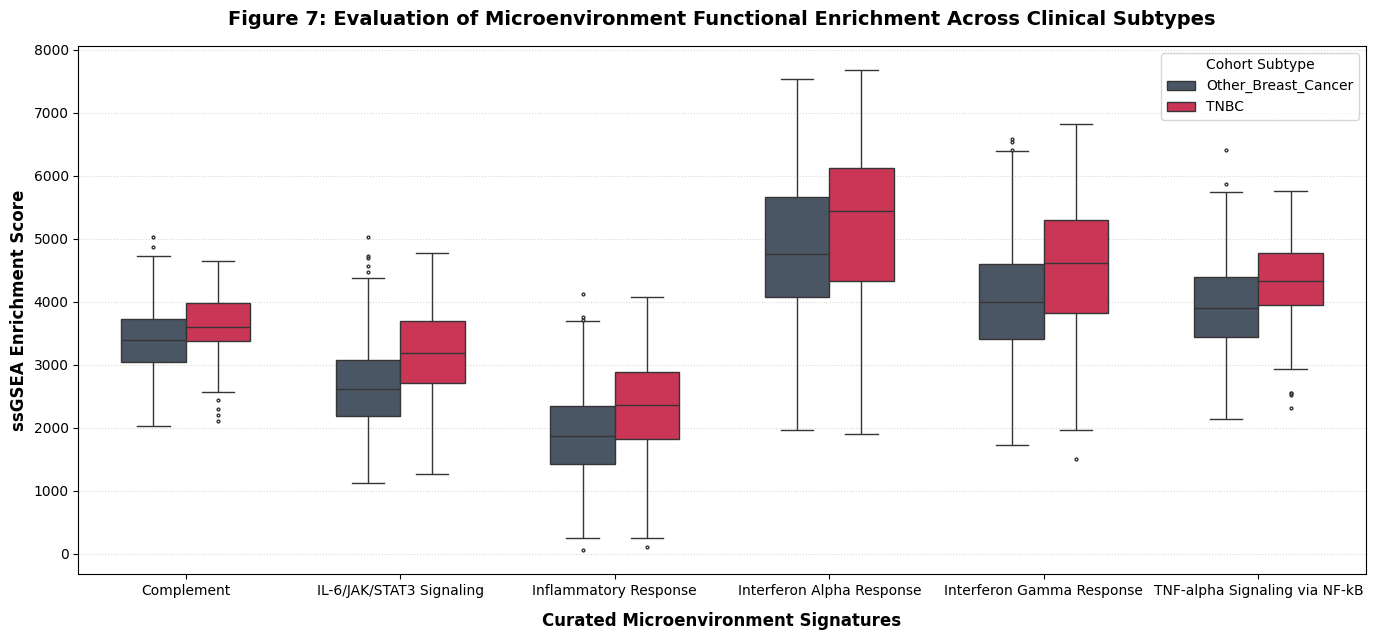

In [5]:
melted_df = merged_df.melt(id_vars=['condition_group'], value_vars=pathways, 
                           var_name='Pathway', value_name='Enrichr_Score')

fig, ax = plt.subplots(figsize=(14, 6.5))
sns.boxplot(
    data=melted_df,
    x='Pathway',
    y='Enrichr_Score',
    hue='condition_group',
    palette={'TNBC': '#E11D48', 'Other_Breast_Cancer': '#475569'},
    ax=ax,
    width=0.6,
    fliersize=2
)

ax.set_xlabel('Curated Microenvironment Signatures', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('ssGSEA Enrichment Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 7: Evaluation of Microenvironment Functional Enrichment Across Clinical Subtypes', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(title='Cohort Subtype', loc='upper right')

plt.tight_layout()
plt.savefig('../results/figures/immune_pathway_boxplots.png', dpi=300, bbox_inches='tight')

### Biological Interpretation

Across all six immune Hallmark signatures, TNBC demonstrates consistently higher pathway activity than other breast cancer subtypes.

The largest differences are observed for:

- Interferon-α Response
- Interferon-γ Response
- TNF-α Signaling via NF-κB
- IL6/JAK/STAT3 Signaling

These findings suggest that TNBC tumors exhibit a more immunologically active microenvironment characterized by enhanced cytokine signaling, inflammatory responses, and interferon-mediated immune activation.

This observation agrees with previous studies describing TNBC as one of the most immune-infiltrated breast cancer subtypes.

### 5. Unsupervised Clustering of Immune Programs (Figure 8)

Hierarchical clustering was performed using patient-specific immune enrichment scores to investigate global patterns of immune heterogeneity across the cohort.

Unlike the previous analysis, clustering does not use clinical subtype information when grouping patients.

Instead, tumors are organized solely according to similarities in their immune pathway activity, allowing natural immune phenotypes to emerge from the data.

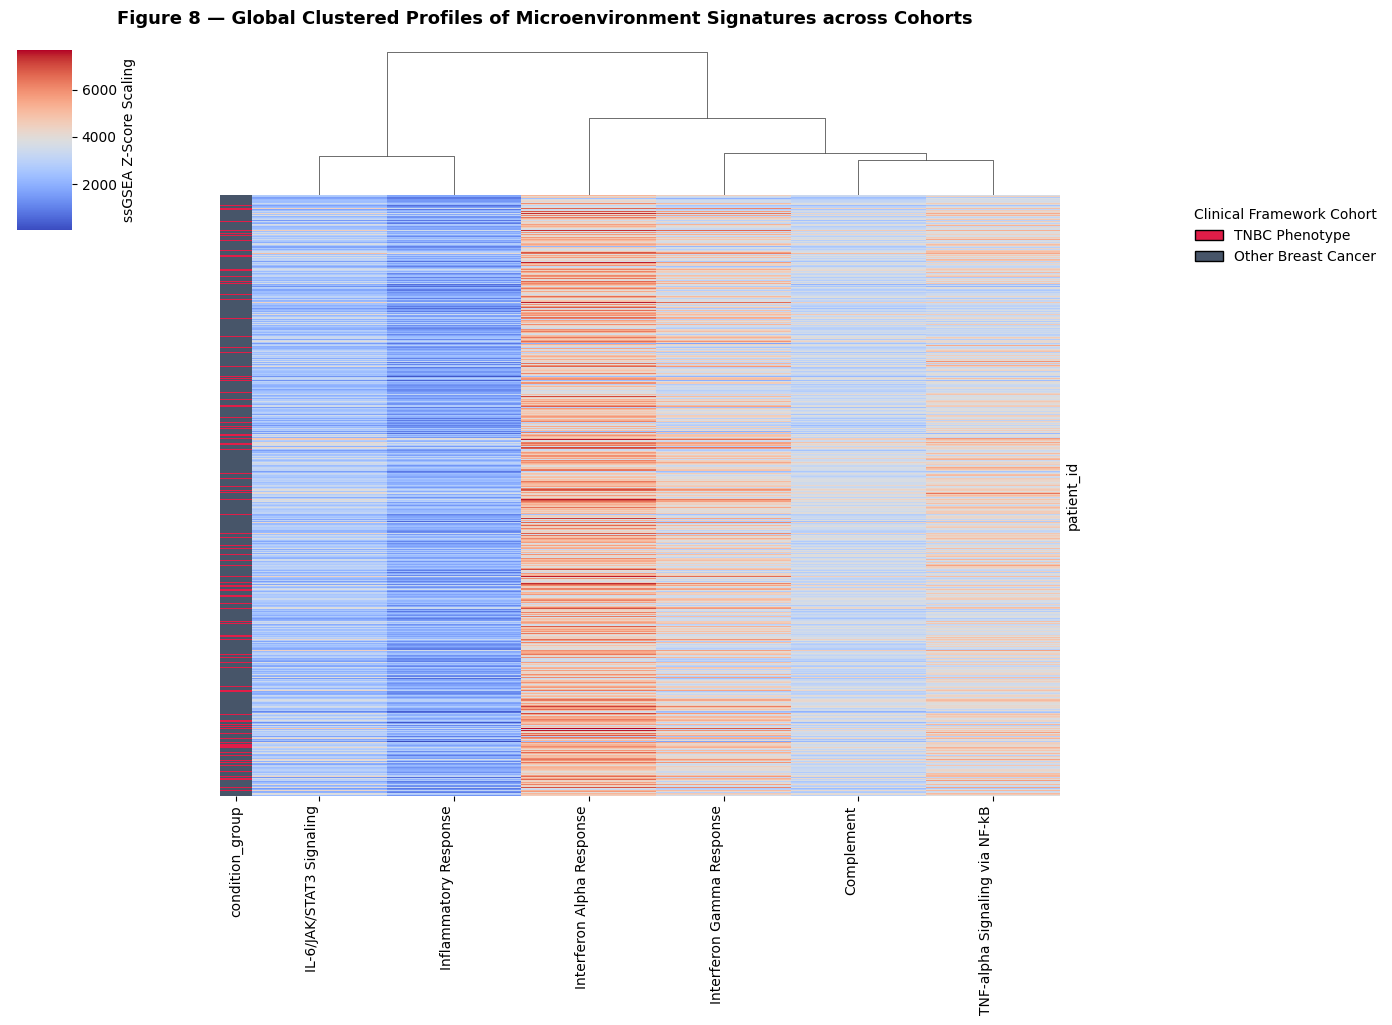

In [6]:
cohort_labels = merged_df['condition_group']
lut = {'TNBC': '#E11D48', 'Other_Breast_Cancer': '#475569'}
row_colors = cohort_labels.map(lut)

g = sns.clustermap(
    scores,
    cmap='coolwarm',
    metric='euclidean',
    method='ward',
    row_colors=row_colors,
    row_cluster=False,       
    xticklabels=True,        
    yticklabels=False,       
    figsize=(11, 10),         
    cbar_kws={'label': 'ssGSEA Z-Score Scaling', 'shrink': 0.5} 
)


plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=10)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E11D48', edgecolor='black', label='TNBC Phenotype'),
    Patch(facecolor='#475569', edgecolor='black', label='Other Breast Cancer')
]

g.ax_heatmap.legend(
    handles=legend_elements, 
    title='Clinical Framework Cohort', 
    loc='upper left', 
    bbox_to_anchor=(1.15, 1.0), 
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

g.fig.suptitle('Figure 8 — Global Clustered Profiles of Microenvironment Signatures across Cohorts', fontsize=13, fontweight='bold', y=1.02)

plt.savefig('../results/figures/immune_signature_heatmap.png', dpi=300, bbox_inches='tight')

### Biological Interpretation

Hierarchical clustering reveals substantial heterogeneity in immune pathway activity among breast tumors.

Several immune signatures cluster together, indicating coordinated regulation of inflammatory and interferon-mediated immune responses.

Patient clustering further demonstrates that immune activation exists along a continuum rather than as discrete categories, highlighting the diversity of immune microenvironments within breast cancer.

These results emphasize that individual tumors can possess distinct immune states despite belonging to the same clinical subtype.

### Notebook Summary

In this notebook, immune pathway activity was systematically compared between Triple-Negative Breast Cancer and other breast cancer subtypes.

Major analyses completed include:

- statistical comparison of immune pathway activity using Mann–Whitney U tests,
- correction for multiple testing using the Benjamini–Hochberg False Discovery Rate,
- visualization of cohort-level immune differences using boxplots,
- unsupervised clustering of tumors based on immune pathway activity,
- evaluation of pathway co-regulation through Spearman correlation analysis.

Collectively, these analyses demonstrate that TNBC exhibits broadly elevated immune pathway activity relative to other breast cancer subtypes and reveal coordinated activation of inflammatory and interferon-related signaling programs within the tumor microenvironment.

These immune phenotypes provide an important biological context for the integrative analyses performed in the subsequent notebooks, where inherited breast cancer susceptibility genes are examined in relation to tumor immune programs.